In [1]:
using Pkg;
Pkg.activate(@__DIR__)
Pkg.instantiate()


  Activating project at `C:\VAASAVI\Dropbox\Education\OSU\Ongoing_Research\Populism\political-polarization\p`


In [2]:
# TODO: rerun with EV saved — current results use V not EV for voting comparison
# qualitatively equivalent for conference, fix before submission
using Interpolations
using CairoMakie
using JLD2
using Statistics
using LaTeXStrings
using Printf
# using GLMakie

include("src/ModelTypes.jl")
@printf("Loaded ModelTypes.jl\n")

include("src/Compute.jl")
@printf("Loaded Compute.jl\n")

include("src/DistrTools.jl")
@printf("Loaded DistrTools.jl\n")

include("src/ModelFunctions.jl")
@printf("Loaded ModelFunctions.jl\n")

include("src/EGM.jl")
@printf("Loaded EGM.jl\n")

include("src/Solvers.jl")
@printf("Loaded Solvers.jl\n")

include("src/SteadyState.jl")
@printf("Loaded Steady States.jl\n")

include("src/Predict.jl")
@printf("Loaded Predict.jl\n")

using .ModelTypes
using .Compute
using .EGM
using .DistrTools
using .Solvers
using .SteadyState
using .Predict
using .ModelFunctions

Loaded ModelTypes.jl
Loaded Compute.jl
Loaded DistrTools.jl
Loaded ModelFunctions.jl
Loaded EGM.jl
Loaded Solvers.jl
Loaded Steady States.jl
Loaded Predict.jl


Okay, so basically choosing which "K" to compare voting rules across is the name of the game. What I've chosen to do is instead calculate what the average capital is in my plain ol' Aiyagari setup, and use that as the K at which I'll compare voting rules. To start, I'll assume the TFP process is also "neutral" (so at the median of the grid). 

In [23]:

# load results
@load "../d/KS_Solves_2026-07-10_2124_nl15.jld2" results params zt

# unpack grids
agrid = params.agrid
lgrid = params.lgrid
zgrid = params.zgrid
Kgrid = params.Kgrid

# baseline: a regular KS equilibrium of the aiyagari model. Then I can get voting rules from that capital
baseline = results[(0.0, 0)]
K_base = mean(baseline.Kt[501:end])
ix, we = weight(params.Kgrid, K_base)


(19, 0.2524237447255375)

In [24]:
keys(results)

KeySet for a Dict{Tuple{Float64, Float64}, NamedTuple} with 100 entries. Keys:
  (0.0, 0.16)
  (0.14, 0.18)
  (0.08, 0.06)
  (0.02, 0.0)
  (0.18, 0.08)
  (0.08, 0.04)
  (0.02, 0.18)
  (0.14, 0.16)
  (0.1, 0.08)
  (0.04, 0.1)
  (0.18, 0.14)
  (0.12, 0.12)
  (0.02, 0.16)
  (0.1, 0.14)
  (0.04, 0.0)
  (0.04, 0.18)
  (0.16, 0.12)
  (0.06, 0.02)
  (0.0, 0.12)
  (0.12, 0.06)
  (0.18, 0.1)
  (0.04, 0.16)
  (0.12, 0.04)
  (0.1, 0.1)
  (0.14, 0.12)
  ⋮

First showing how migration changes this "threshold"

In [25]:
@printf("K_base = %.4f, Kgrid[ix] = %.4f\n", K_base, Kgrid[ix])

K_base = 46.1661, Kgrid[ix] = 46.0000


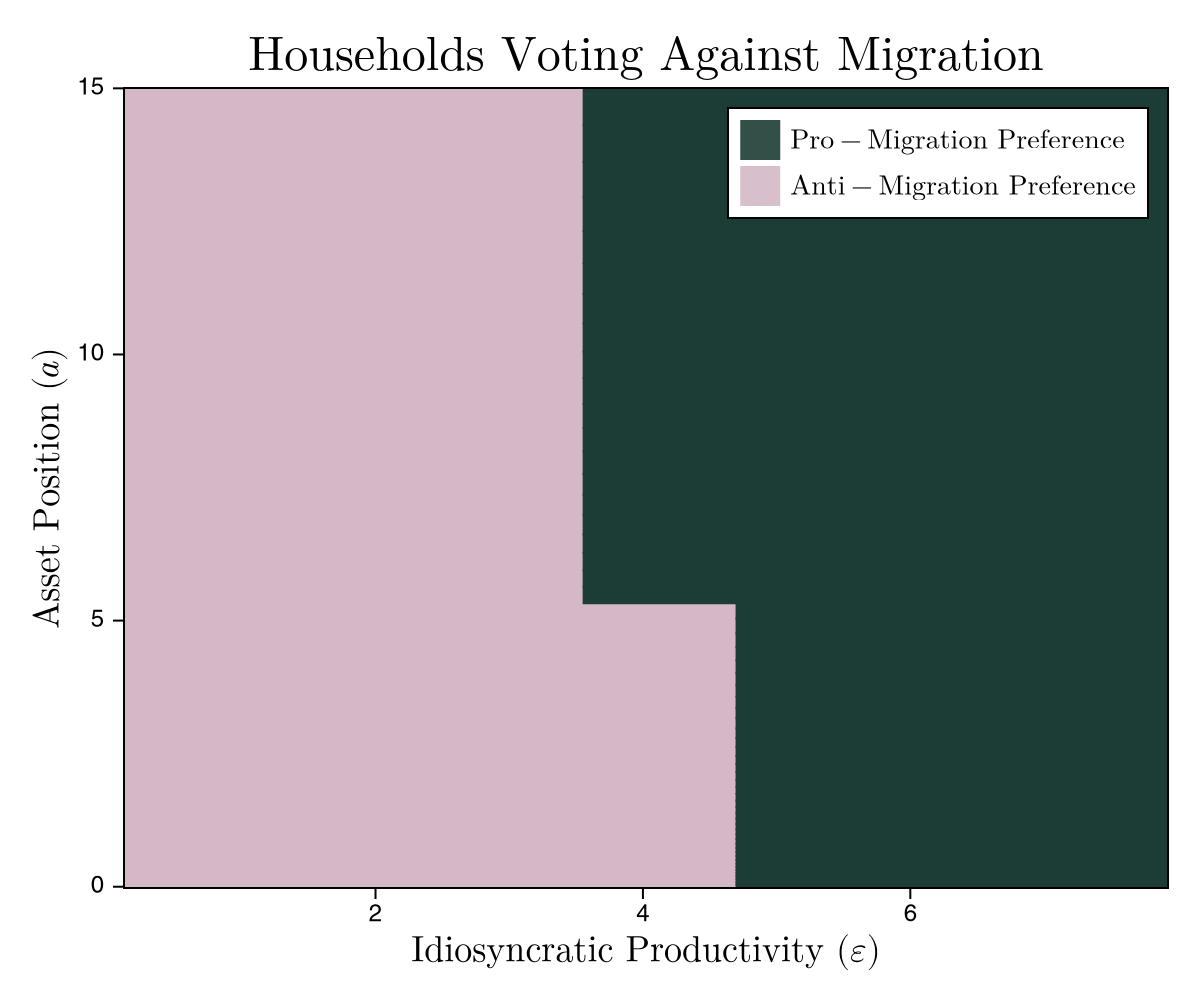

In [26]:
incumbent  = results[(0.04, 0.0)]
challenger =  results[(0.0, 0.0)]  # some migration, no redistribution

futureKs = futureKs = exp.(incumbent.Kfore[:, 1] .+ incumbent.Kfore[:, 2] .* log.(Kgrid)')
EV_i = getExpectationKS(futureKs, incumbent.V, params)
EV_i = we*EV_i[ix,:,:,:] + (1-we)*EV_i[ix+1,:,:,:]

# pick a comparison
futureKs = futureKs = exp.(challenger.Kfore[:, 1] .+ challenger.Kfore[:, 2] .* log.(Kgrid)')
EV_c = getExpectationKS(futureKs, challenger.V, params)
EV_c = we*EV_c[ix,:,:,:] + (1-we)*EV_c[ix+1,:,:,:]

# welfare difference — collapse TFP dimension by averaging
mean_TFP = 2; # good times
EV_i = EV_i[mean_TFP,:,:]   # (nl, na)
EV_c = EV_c[mean_TFP,:,:]

diffs = EV_c .- EV_i;   # positive = prefers challenger

# for each labor state, find the asset threshold
# (highest asset level where household still votes for comp)

nl = length(lgrid); na = length(agrid);

votes = diffs .> 0.0;

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title = L"\text{Households Voting Against Migration}")
# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid[1:60], (diffs[:,1:60] .> 0.0),
    colormap = [("#1C3D35"), ("#D4B8C7")])

elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [L"\text{Pro-Migration Preference}",  L"\text{Anti-Migration Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_baseline_ks_mig_small_quarterly.pdf", fig)
fig

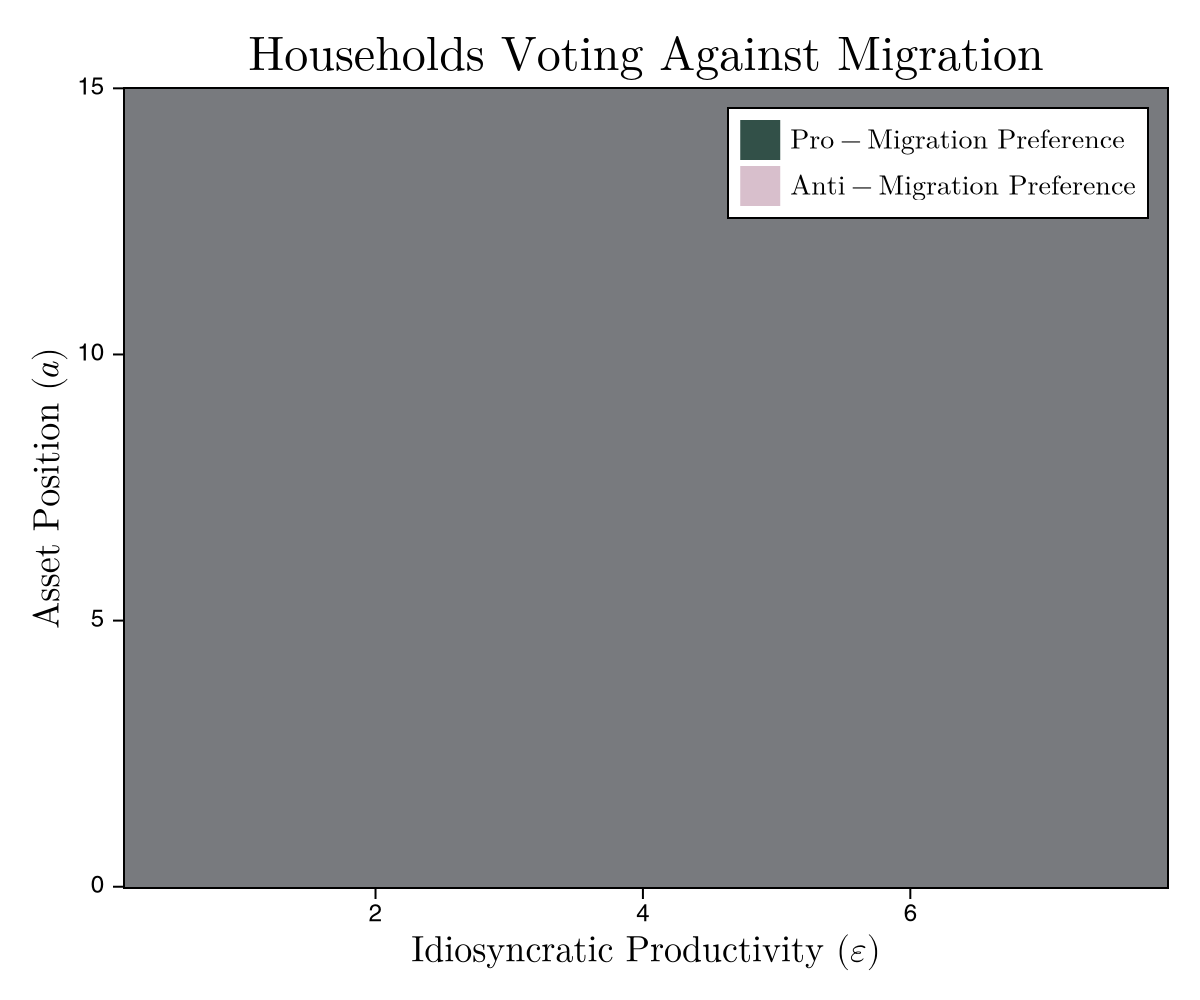

In [27]:
# pick a comparison
incumbent  = results[(0.08, 0.0)] 
challenger = results[(0.0, 0.0)]

futureKs = futureKs = exp.(incumbent.Kfore[:, 1] .+ incumbent.Kfore[:, 2] .* log.(Kgrid)')
EV_i = getExpectationKS(futureKs, incumbent.V, params)
EV_i = we*EV_i[ix,:,:,:] + (1-we)*EV_i[ix+1,:,:,:]

futureKs = exp.(challenger.Kfore[:, 1] .+ challenger.Kfore[:, 2] .* log.(Kgrid)')
EV_c = getExpectationKS(futureKs, challenger.V, params)
EV_c = we*EV_c[ix,:,:,:] + (1-we)*EV_c[ix+1,:,:,:]

# welfare difference — collapse TFP dimension by averaging
mean_TFP = cld(length(zgrid), 2)
EV_i = EV_i[mean_TFP,:,:]   # (nl, na)
EV_c = EV_c[mean_TFP,:,:]

diffs = EV_c .- EV_i;   # positive = prefers challenger

# for each labor state, find the asset threshold
# (highest asset level where household still votes for comp)

nl = length(lgrid); na = length(agrid);

votes = diffs .> 0.0;

votes

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title = L"\text{Households Voting Against Migration}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid[1:60], (diffs[:,1:60] .> 0.0),
    colormap = [("#1C3D35"), ("#D4B8C7")])

elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [L"\text{Pro-Migration Preference}",  L"\text{Anti-Migration Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_baseline_ks_mig_big_quarterly.pdf", fig)
fig

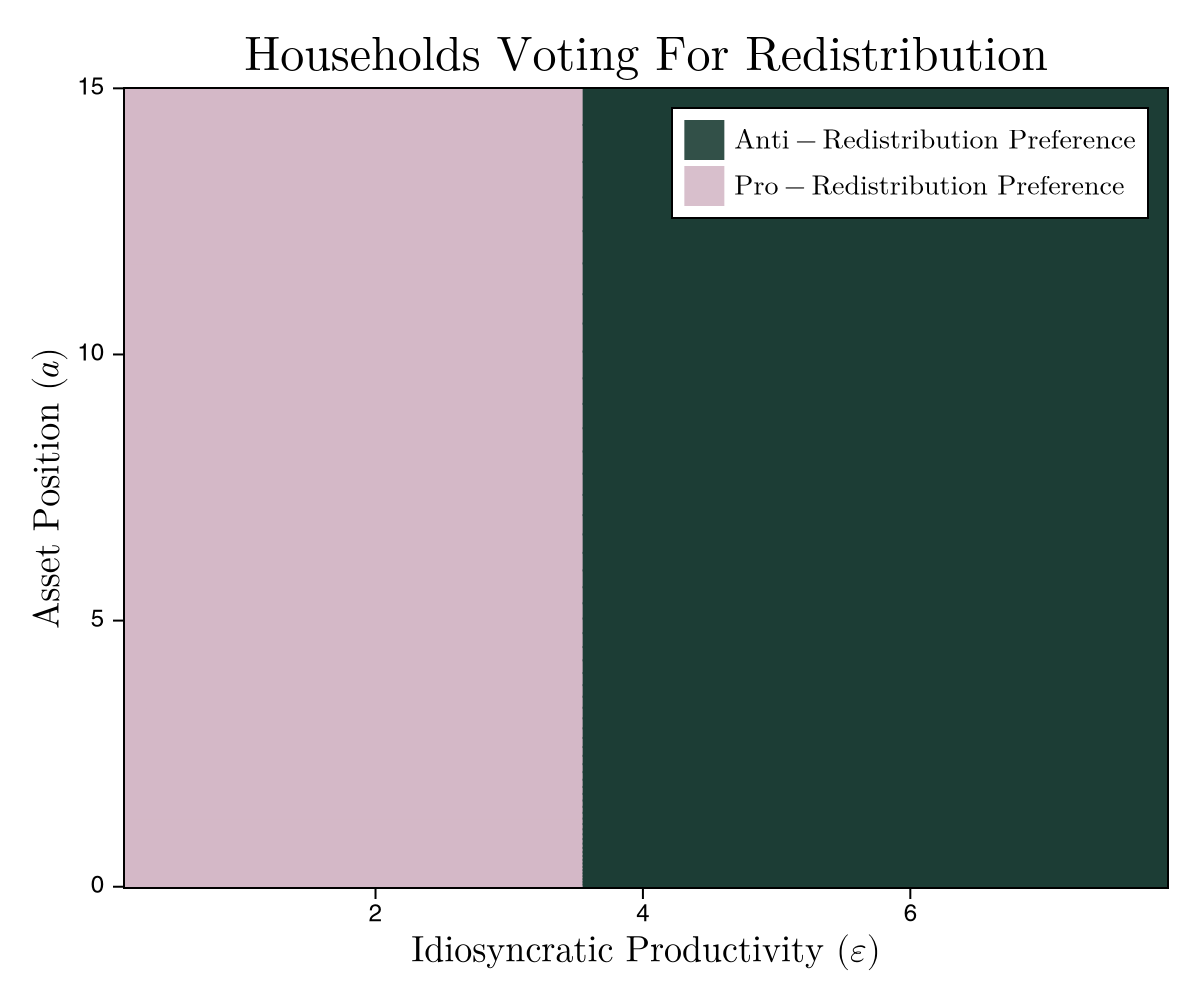

In [28]:
# pick a comparison
incumbent  = results[(0.0, 0.0)]
challenger = results[(0.0, 0.04)]   # redistribution

futureKs = futureKs = exp.(incumbent.Kfore[:, 1] .+ incumbent.Kfore[:, 2] .* log.(Kgrid)')
EV_i = getExpectationKS(futureKs, incumbent.V, params)
EV_i = we*EV_i[ix,:,:,:] + (1-we)*EV_i[ix+1,:,:,:]

futureKs = exp.(challenger.Kfore[:, 1] .+ challenger.Kfore[:, 2] .* log.(Kgrid)')
EV_c = getExpectationKS(futureKs, challenger.V, params)
EV_c = we*EV_c[ix,:,:,:] + (1-we)*EV_c[ix+1,:,:,:]

# welfare difference — collapse TFP dimension by averaging
mean_TFP = cld(length(zgrid), 2)
EV_i = EV_i[mean_TFP,:,:]   # (nl, na)
EV_c = EV_c[mean_TFP,:,:]

diffs = EV_c .- EV_i;   # positive = prefers challenger

# for each labor state, find the asset threshold
# (highest asset level where household still votes for comp)

nl = length(lgrid); na = length(agrid);

votes = diffs .> 0.0;

votes

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title = L"\text{Households Voting For Redistribution}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid[1:60], (diffs[:,1:60] .> 0.0),
    colormap = [("#1C3D35"), ("#D4B8C7")])

elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Anti-Redistribution Preference}", L"\text{Pro-Redistribution Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_baseline_ks_redist_small_quarterly.pdf", fig)
fig

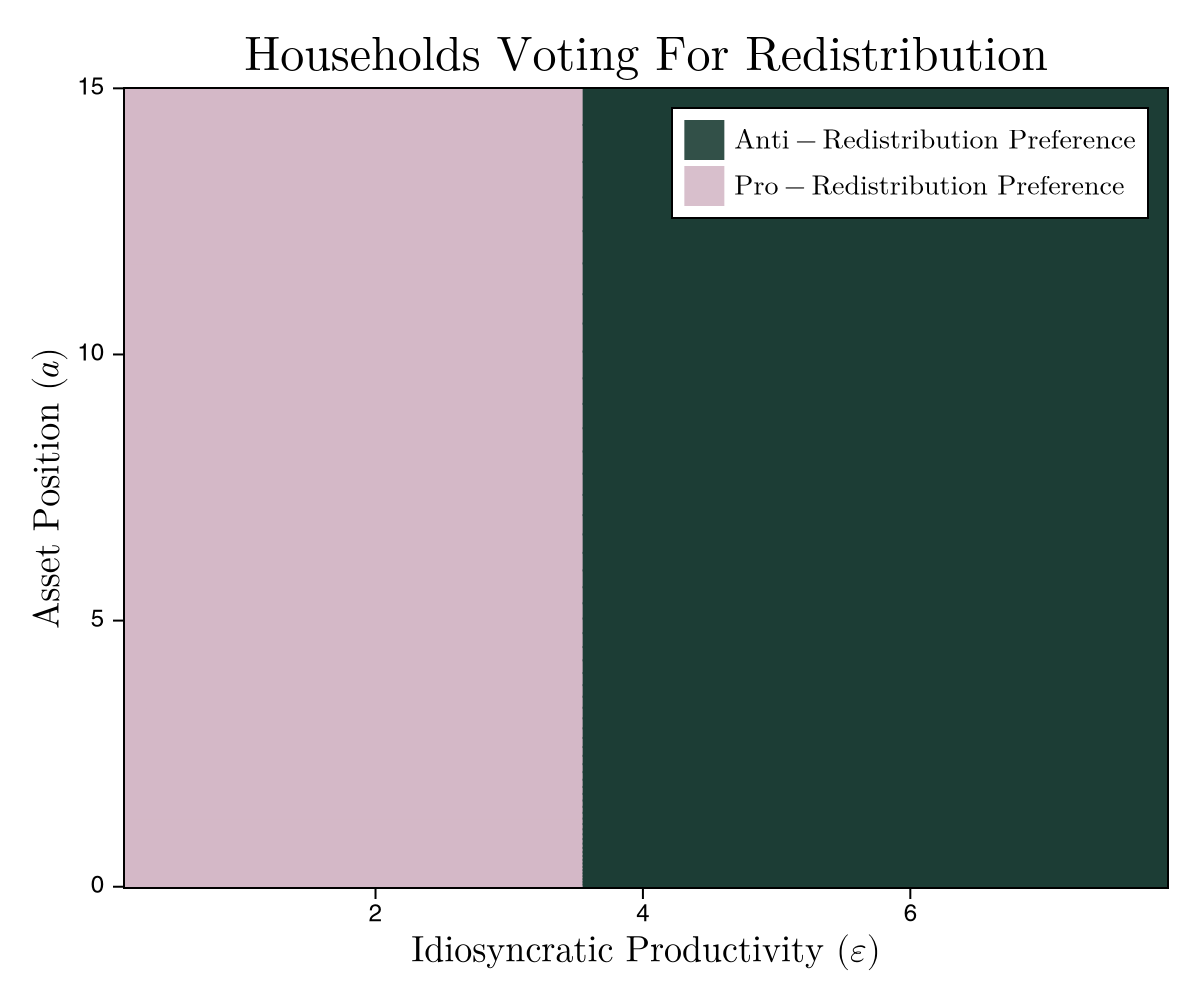

In [29]:
# pick a comparison
incumbent  = results[(0.0, 0.0)]
challenger = results[(0.0, 0.14)]   # some migration, no redistribution

futureKs = futureKs = exp.(incumbent.Kfore[:, 1] .+ incumbent.Kfore[:, 2] .* log.(Kgrid)')
EV_i = getExpectationKS(futureKs, incumbent.V, params)
EV_i = we*EV_i[ix,:,:,:] + (1-we)*EV_i[ix+1,:,:,:]

futureKs = exp.(challenger.Kfore[:, 1] .+ challenger.Kfore[:, 2] .* log.(Kgrid)')
EV_c = getExpectationKS(futureKs, challenger.V, params)
EV_c = we*EV_c[ix,:,:,:] + (1-we)*EV_c[ix+1,:,:,:]

# welfare difference — collapse TFP dimension by averaging
mean_TFP = cld(length(zgrid), 2)
EV_i = EV_i[mean_TFP,:,:]   # (nl, na)
EV_c = EV_c[mean_TFP,:,:]

diffs = EV_c .- EV_i;   # positive = prefers challenger

# for each labor state, find the asset threshold
# (highest asset level where household still votes for comp)

nl = length(lgrid); na = length(agrid);

votes = diffs .> 0.0;

votes

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title = L"\text{Households Voting For Redistribution}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid[1:60], (diffs[:,1:60] .> 0.0),
    colormap = [("#1C3D35"), ("#D4B8C7")])

elem1 = PolyElement(color=("#1C3D35", 0.9))
elem2 = PolyElement(color=("#D4B8C7", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Anti-Redistribution Preference}", L"\text{Pro-Redistribution Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_baseline_ks_redist_big_quarterly.pdf", fig)
fig

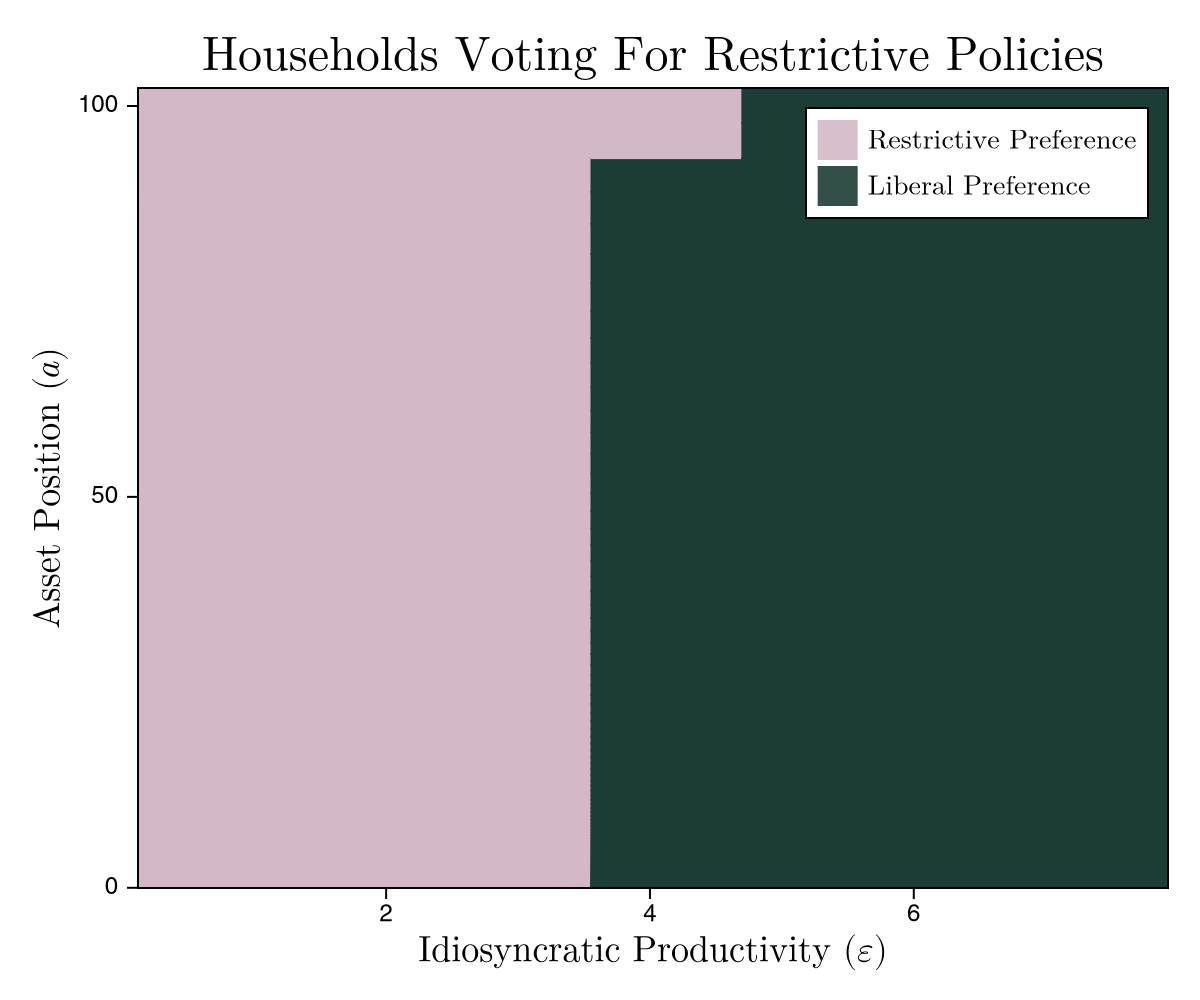

In [30]:
# pick a comparison
incumbent  = results[(0.08, 0.0)]
challenger = results[(0.04, 0.08)]   # some migration, some redistribution

futureKs = futureKs = exp.(incumbent.Kfore[:, 1] .+ incumbent.Kfore[:, 2] .* log.(Kgrid)')
EV_i = getExpectationKS(futureKs, incumbent.V, params)
EV_i = we*EV_i[ix,:,:,:] + (1-we)*EV_i[ix+1,:,:,:]

futureKs = exp.(challenger.Kfore[:, 1] .+ challenger.Kfore[:, 2] .* log.(Kgrid)')
EV_c = getExpectationKS(futureKs, challenger.V, params)
EV_c = we*EV_c[ix,:,:,:] + (1-we)*EV_c[ix+1,:,:,:]

# welfare difference — collapse TFP dimension by averaging
mean_TFP = cld(length(zgrid), 2)
EV_i = EV_i[mean_TFP,:,:]   # (nl, na)
EV_c = EV_c[mean_TFP,:,:]

diffs = EV_c .- EV_i;   # positive = prefers challenger

# for each labor state, find the asset threshold
# (highest asset level where household still votes for comp)

nl = length(lgrid); na = length(agrid);

votes = diffs .> 0.0;

votes

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title = L"\text{Households Voting For Restrictive Policies}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid, (diffs .> 0.0),
    colormap = [("#1C3D35"), ("#D4B8C7")])

elem1 = PolyElement(color=("#D4B8C7", 0.9))
elem2 = PolyElement(color=("#1C3D35", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Restrictive Preference}", L"\text{Liberal Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_baseline_ks_both_small_quarterly.pdf", fig)
fig

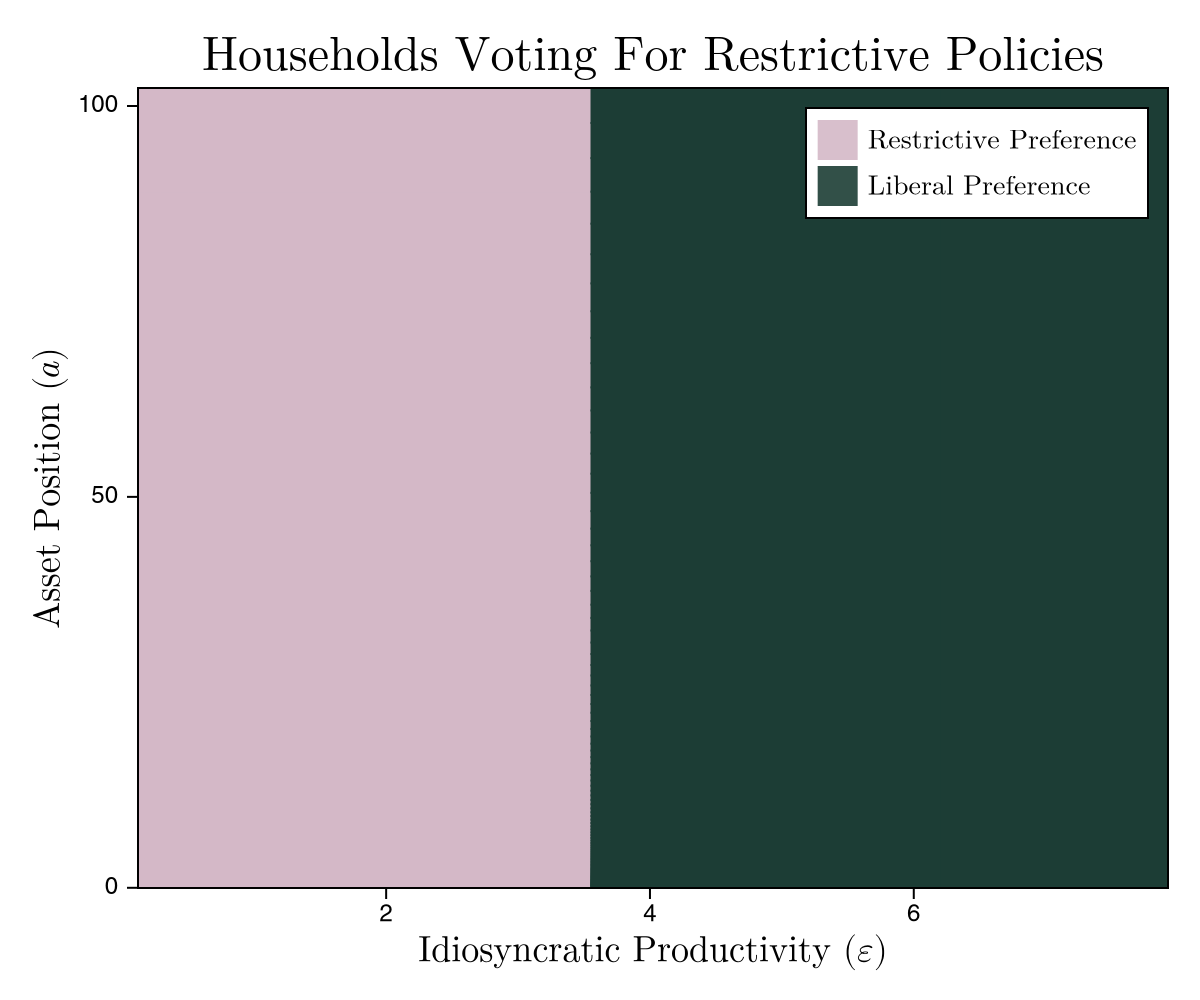

In [31]:
# pick a comparison
incumbent  = results[(0.08, 0.00)]
challenger = results[(0.00, 0.08)]   # no migration, redistribution

futureKs = futureKs = exp.(incumbent.Kfore[:, 1] .+ incumbent.Kfore[:, 2] .* log.(Kgrid)')
EV_i = getExpectationKS(futureKs, incumbent.V, params)
EV_i = we*EV_i[ix,:,:,:] + (1-we)*EV_i[ix+1,:,:,:]

futureKs = exp.(challenger.Kfore[:, 1] .+ challenger.Kfore[:, 2] .* log.(Kgrid)')
EV_c = getExpectationKS(futureKs, challenger.V, params)
EV_c = we*EV_c[ix,:,:,:] + (1-we)*EV_c[ix+1,:,:,:]

# welfare difference — collapse TFP dimension by averaging
mean_TFP = cld(length(zgrid), 2)
EV_i = EV_i[mean_TFP,:,:]   # (nl, na)
EV_c = EV_c[mean_TFP,:,:]

diffs = EV_c .- EV_i;   # positive = prefers challenger

# for each labor state, find the asset threshold
# (highest asset level where household still votes for comp)

nl = length(lgrid); na = length(agrid);

votes = diffs .> 0.0;

votes

set_theme!(
    fonts = (regular = "Helvetica", bold = "Helvetica Bold"),
    fontsize = 14,
    Axis = (
        titlesize = 24,
        xlabelsize = 18,
        ylabelsize = 18,
        xticklabelsize = 12,
        yticklabelsize = 12,
        titlefont = "Helvetica Bold",
        xlabelfont = "Helvetica",
        ylabelfont = "Helvetica",
        xticklabelfont = "Helvetica",
        yticklabelfont = "Helvetica",
    )
)

fig = Figure(size=(600, 500))
ax = Axis(fig[1,1],
    xlabel = L"\text{Idiosyncratic Productivity }($\varepsilon$)",
    ylabel = L"\text{Asset Position }(a)",
    title = L"\text{Households Voting For Restrictive Policies}")

# diffs is (nl, na) — rows are labor states, columns are asset states
# heatmap expects (x, y, z) where z[i,j] corresponds to x[i], y[j]
heatmap!(ax, lgrid, agrid, (diffs .> 0.0),
    colormap = [("#1C3D35"), ("#D4B8C7")])

elem1 = PolyElement(color=("#D4B8C7", 0.9))
elem2 = PolyElement(color=("#1C3D35", 0.9))
Legend(fig[1,1], [elem1, elem2], [ L"\text{Restrictive Preference}", L"\text{Liberal Preference}"],
       tellwidth=false, tellheight=false,
       halign=:right, valign=:top, margin=(10,10,10,10))

save("../v/voting_baseline_ks_both_big_quarterly.pdf", fig)
fig

Now adding in a graph to see how K itself changes across the policy space.

Now switching over to looking at how a one-time shock would effect voting shares over time. The main sort of thing is showing three things: 

1. Preferences for migration after a z shock
2. Preferences for redistributive taxation after a z shock
3. Preferences for migration, holding redistribution at a non-zero level

First generate the $z_t$ path

In [32]:
zhigh = 2     # good times
zlow = 1              # z-index of the lowest (recession) state

zt_shock = vcat(fill(zhigh, 500), fill(zlow, 6), fill(zhigh, 500));

In [33]:
incumbent  = results[(0.02, 0.08)]   # some migration, no redistribution
challenger = results[(0.00, 0.18)]   # no migration, some redistribution

share_path, Kt = voteSharePath(incumbent, challenger, zt_shock, params);

In [34]:
incumbent2  = results[(0.02, 0.16)]   # some migration, no redistribution

share_path2, Kt2 = voteSharePath(incumbent2, challenger, zt_shock, params);

In [35]:
# incumbent  = results[(0.045, 0.09)]   # some migration, no redistribution
# challenger = results[(0.00, 0.135)]
# incumbent2  = results[(0.045, 0.135)]

# ks output
println(extrema(challenger.Kt[500:end]))
println(extrema(incumbent.Kt[500:end]))
println(extrema(incumbent2.Kt[500:end]))

# capital shock paths
println(Kt[498:515])
println(Kt2[498:515])


println(incumbent.Kfore == incumbent2.Kfore)   # are the forecasts actually different?
println(incumbent.G == incumbent2.G)            # and the policy funcs?

(42.633144424757475, 45.24119653453655)
(43.84573489751919, 46.37985866601621)
(42.11971668982641, 44.707049468010325)
[46.4395217410165, 46.43952114257387, 46.43952055805633, 46.43951998715449, 46.336271686575586, 46.23534387026609, 46.13668702831309, 46.040261754435, 45.94602183023724, 45.853925869537136, 45.86752866670805, 45.880874270119236, 45.89395209050592, 45.90675488321501, 45.91927807222854, 45.93151928893442, 45.94347805235602, 45.95515537479519]
[44.76679744813863, 44.766796068616486, 44.76679472500357, 44.766793416470996, 44.66147480342869, 44.55853326860032, 44.45792262146425, 44.359587802970275, 44.26348475934351, 44.169562862084106, 44.18329073282287, 44.19675788730314, 44.209955847402, 44.222879153463, 44.235524362727205, 44.247886302733775, 44.259965176800264, 44.271762489066205]
false
false


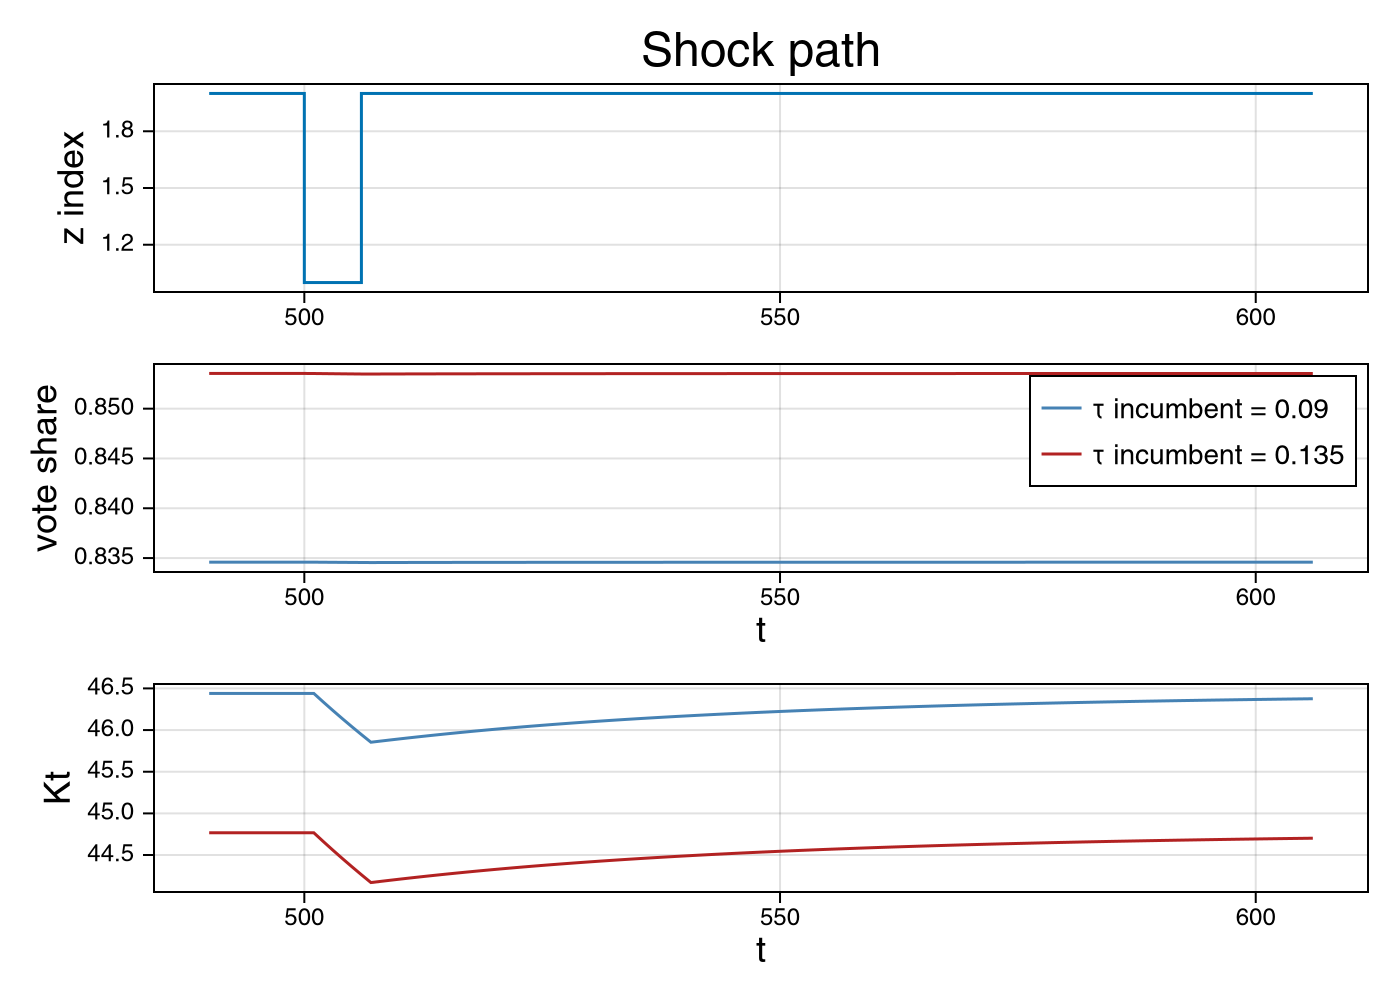

In [36]:
NT = length(share_path)
window = 490:(NT-400)

# baseline = pre-shock level, taken at the first period in the window
base1 = share_path[window[1]]
base2 = share_path2[window[1]]

pct1 = (share_path .- base1) ./ base1 .* 100
pct2 = (share_path2 .- base2) ./ base2 .* 100


fig = Figure(size = (700, 500))

ax1 = Axis(fig[1, 1], ylabel = "z index", title = "Shock path")
stairs!(ax1, window, zt_shock[window])

ax2 = Axis(fig[2, 1], ylabel = "vote share", xlabel = "t")
l1 = lines!(ax2, window, share_path[window], color = :steelblue, label = "τ incumbent = 0.09")
l2 = lines!(ax2, window, share_path2[window], color = :firebrick, label = "τ incumbent = 0.135")
axislegend(ax2, position = :rt)

ax3 = Axis(fig[3, 1], ylabel = "Kt", xlabel = "t")
lines!(ax3, window, Kt[window], color = :steelblue)
lines!(ax3, window, Kt2[window], color = :firebrick)

linkxaxes!(ax1, ax2, ax3)
fig


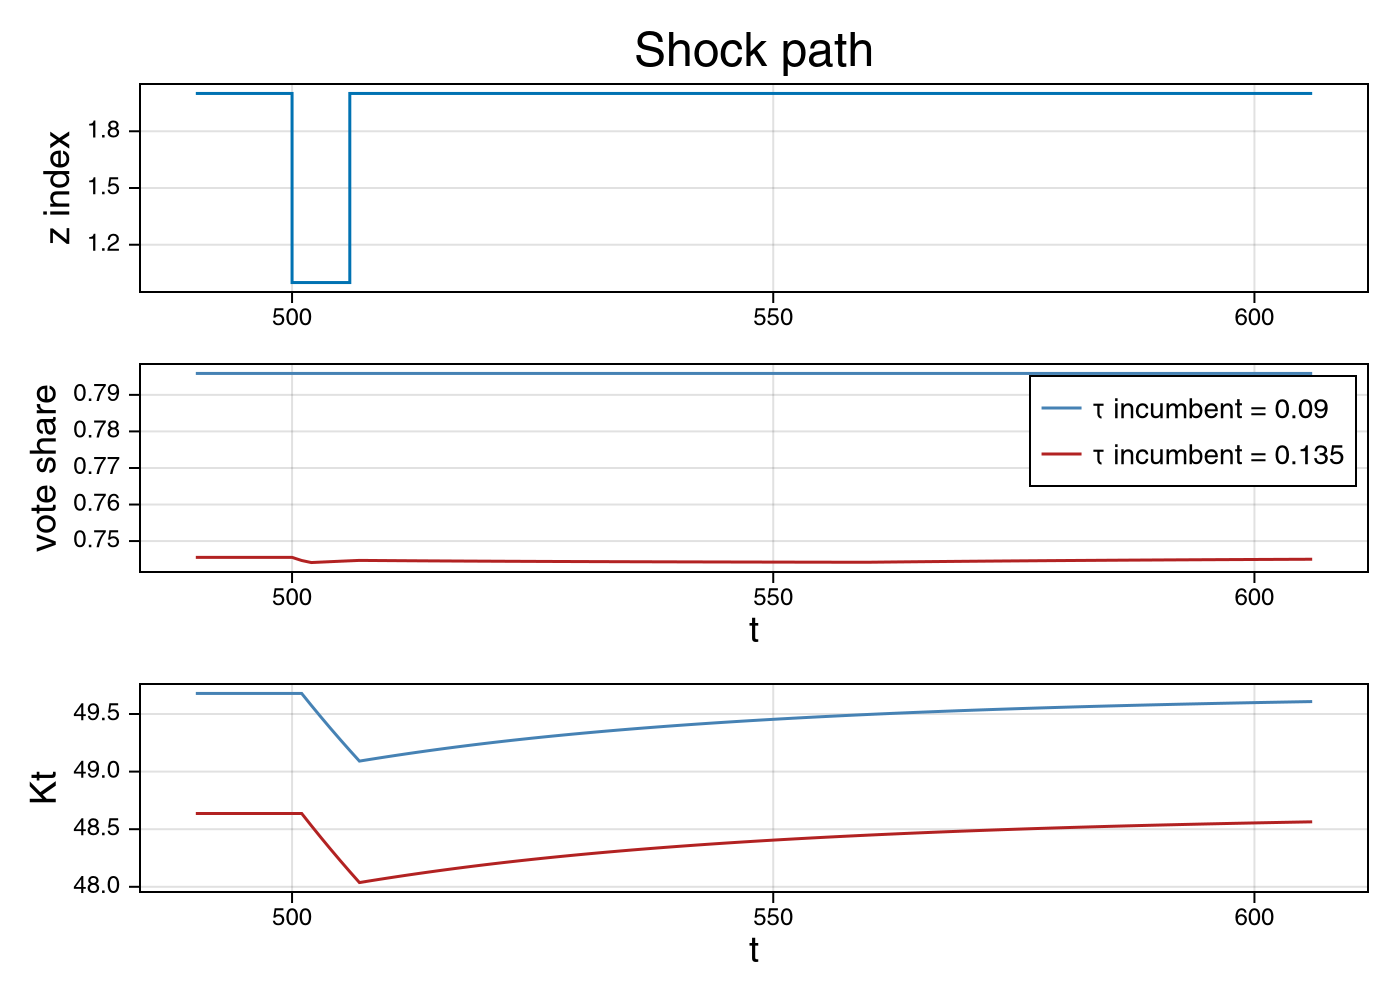

In [43]:
NT = length(share_path)
window = 490:(NT-400)

# baseline = pre-shock level, taken at the first period in the window
base1 = share_path[window[1]]
base2 = share_path2[window[1]]

pct1 = (share_path .- base1) ./ base1 .* 100
pct2 = (share_path2 .- base2) ./ base2 .* 100


NT = length(share_path)
window = 490:(NT-400)

# baseline = pre-shock level, taken at the first period in the window
base1 = share_path[window[1]]
base2 = share_path2[window[1]]

pct1 = (share_path .- base1) ./ base1 .* 100
pct2 = (share_path2 .- base2) ./ base2 .* 100


fig = Figure(size = (700, 500))

ax1 = Axis(fig[1, 1], ylabel = "z index", title = "Shock path")
stairs!(ax1, window, zt_shock[window])

ax2 = Axis(fig[2, 1], ylabel = "vote share", xlabel = "t")
l1 = lines!(ax2, window, share_path[window], color = :steelblue, label = "τ incumbent = 0.09")
l2 = lines!(ax2, window, share_path2[window], color = :firebrick, label = "τ incumbent = 0.135")
axislegend(ax2, position = :rt)

ax3 = Axis(fig[3, 1], ylabel = "Kt", xlabel = "t")
lines!(ax3, window, Kt[window], color = :steelblue)
lines!(ax3, window, Kt2[window], color = :firebrick)

linkxaxes!(ax1, ax2, ax3)
fig


fig = Figure(size = (1000, 700))

ax1 = Axis(fig[1, 1],
    ylabel = L"\text{TFP State }(z)",
    xticks = (collect(500:20:600), string.(collect(0:20:100))))
stairs!(ax1, window, zt_shock[window], color = :steelblue)

ax2 = Axis(fig[2, 1],
    ylabel = L"\text{\% Change in Vote Share}",
    xticks = (collect(500:20:600), string.(collect(0:20:100))))

hlines!(ax2, [0.0], linestyle = :dash, color = :gray)
lines!(ax2, window, pct1[window], color = :steelblue, linewidth = 2)
lines!(ax2, window, pct2[window], color = :firebrick, linewidth = 2)

ax3 = Axis(fig[3, 1],
    xlabel = L"\text{Years since shock}",
    ylabel = L"K_t",
    xticks = (collect(500:20:600), string.(collect(0:20:100))))
lines!(ax3, window, Kt[window], color = :steelblue, linewidth = 2)
lines!(ax3, window, Kt2[window], color = :firebrick, linewidth = 2)

# legend in its own column, spanning all three rows
Legend(fig[4, 1],
    [l1, l2],
    [L"\tau^{\text{incumbent}} = 0.08", L"\tau^{\text{incumbent}} = 0.16"],
    orientation = :horizontal,
    framevisible = false,
    labelsize = 20,
    patchsize = (40, 20),
    linewidth = 4)

rowsize!(fig.layout, 4, Relative(0.08))

linkxaxes!(ax1, ax2, ax3)

save("../v/vote_share_shock_comparison_quarterly.pdf", fig)
fig

In [ ]:
fig = Figure(size = (1000, 700))

ax1 = Axis(fig[1, 1],
    ylabel = L"\text{TFP State }(z)",
    xticks = (collect(500:20:600), string.(collect(0:20:100))))
stairs!(ax1, window, zt_shock[window], color = :steelblue)

ax2 = Axis(fig[2, 1],
    ylabel = L"\text{\% Change in Vote Share}",
    xticks = (collect(500:20:600), string.(collect(0:20:100))))

hlines!(ax2, [0.0], linestyle = :dash, color = :gray)
lines!(ax2, window, pct1[window], color = :steelblue, linewidth = 2)
lines!(ax2, window, pct2[window], color = :firebrick, linewidth = 2)

ax3 = Axis(fig[3, 1],
    xlabel = L"\text{Years since shock}",
    ylabel = L"K_t",
    xticks = (collect(500:20:600), string.(collect(0:20:100))))
lines!(ax3, window, Kt[window], color = :steelblue, linewidth = 2)
lines!(ax3, window, Kt2[window], color = :firebrick, linewidth = 2)

# legend in its own column, spanning all three rows
Legend(fig[4, 1],
    [l1, l2],
    [L"\tau^{\text{incumbent}} = 0.08", L"\tau^{\text{incumbent}} = 0.16"],
    orientation = :horizontal,
    framevisible = false,
    labelsize = 20,
    patchsize = (40, 20),
    linewidth = 4)

rowsize!(fig.layout, 4, Relative(0.08))

linkxaxes!(ax1, ax2, ax3)

save("../v/vote_share_shock_comparison_quarterly.pdf", fig)
fig

In [18]:
display(Kt2 == Kt)

fig = Figure(size = (1000, 700))
ax2 = Axis(fig[1, 1],
    ylabel = L"\text{\% Change in Vote Share}")
lines!(ax2, window, Kt2[window]-Kt[window], color = :steelblue, linewidth = 2)
fig

LoadError: UndefVarError: `Kt2` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [38]:
# peak deviation (most negative point) for each
peak1, t_peak1 = findmin(pct1[window])
peak2, t_peak2 = findmin(pct2[window])
@printf("τ=0.08 peak: %.3f%% at t=%i\n", peak1, window[t_peak1])
@printf("τ=0.18 peak: %.3f%% at t=%i\n", peak2, window[t_peak2])

# recovery time: first period after the trough where |pct change| < some threshold
function recovery_time(pct, window, thresh=0.05)
    pct_w = pct[window]                      # local, window-relative series
    trough_idx = argmin(pct_w)               # local index of the trough
    for i in trough_idx:length(pct_w)
        if abs(pct_w[i]) < thresh
            return window[i]                 # map back to real t only here
        end
    end
    return nothing
end

thresh = 0.05
t1 = recovery_time(pct1, window, thresh)
t2 = recovery_time(pct2, window, thresh)

shock_end = 508
@printf("τ=0.08 recovers by t=%s (%s periods after shock ends)\n",
    t1, t1 === nothing ? "N/A" : string(t1 - shock_end))
@printf("τ=0.18 recovers by t=%s (%s periods after shock ends)\n",
    t2, t2 === nothing ? "N/A" : string(t2 - shock_end))

time_negative(pct, window) = count(x -> x < 0, pct[window])

neg1 = time_negative(pct1, window)
neg2 = time_negative(pct2, window)

@printf("τ=0.08: %i periods with negative deviation\n", neg1)
@printf("τ=0.18: %i periods with negative deviation\n", neg2)

τ=0.08 peak: -0.005% at t=507
τ=0.18 peak: -0.007% at t=507
τ=0.08 recovers by t=507 (-1 periods after shock ends)
τ=0.18 recovers by t=507 (-1 periods after shock ends)
τ=0.08: 105 periods with negative deviation
τ=0.18: 106 periods with negative deviation


τ=0.08 peak: 0.000% at t=490
τ=0.18 peak: -0.190% at t=502
τ=0.08 recovers by t=490 (-18 periods after shock ends)
τ=0.18 recovers by t=nothing (N/A periods after shock ends)
τ=0.08: 0 periods with negative deviation
τ=0.18: 106 periods with negative deviation


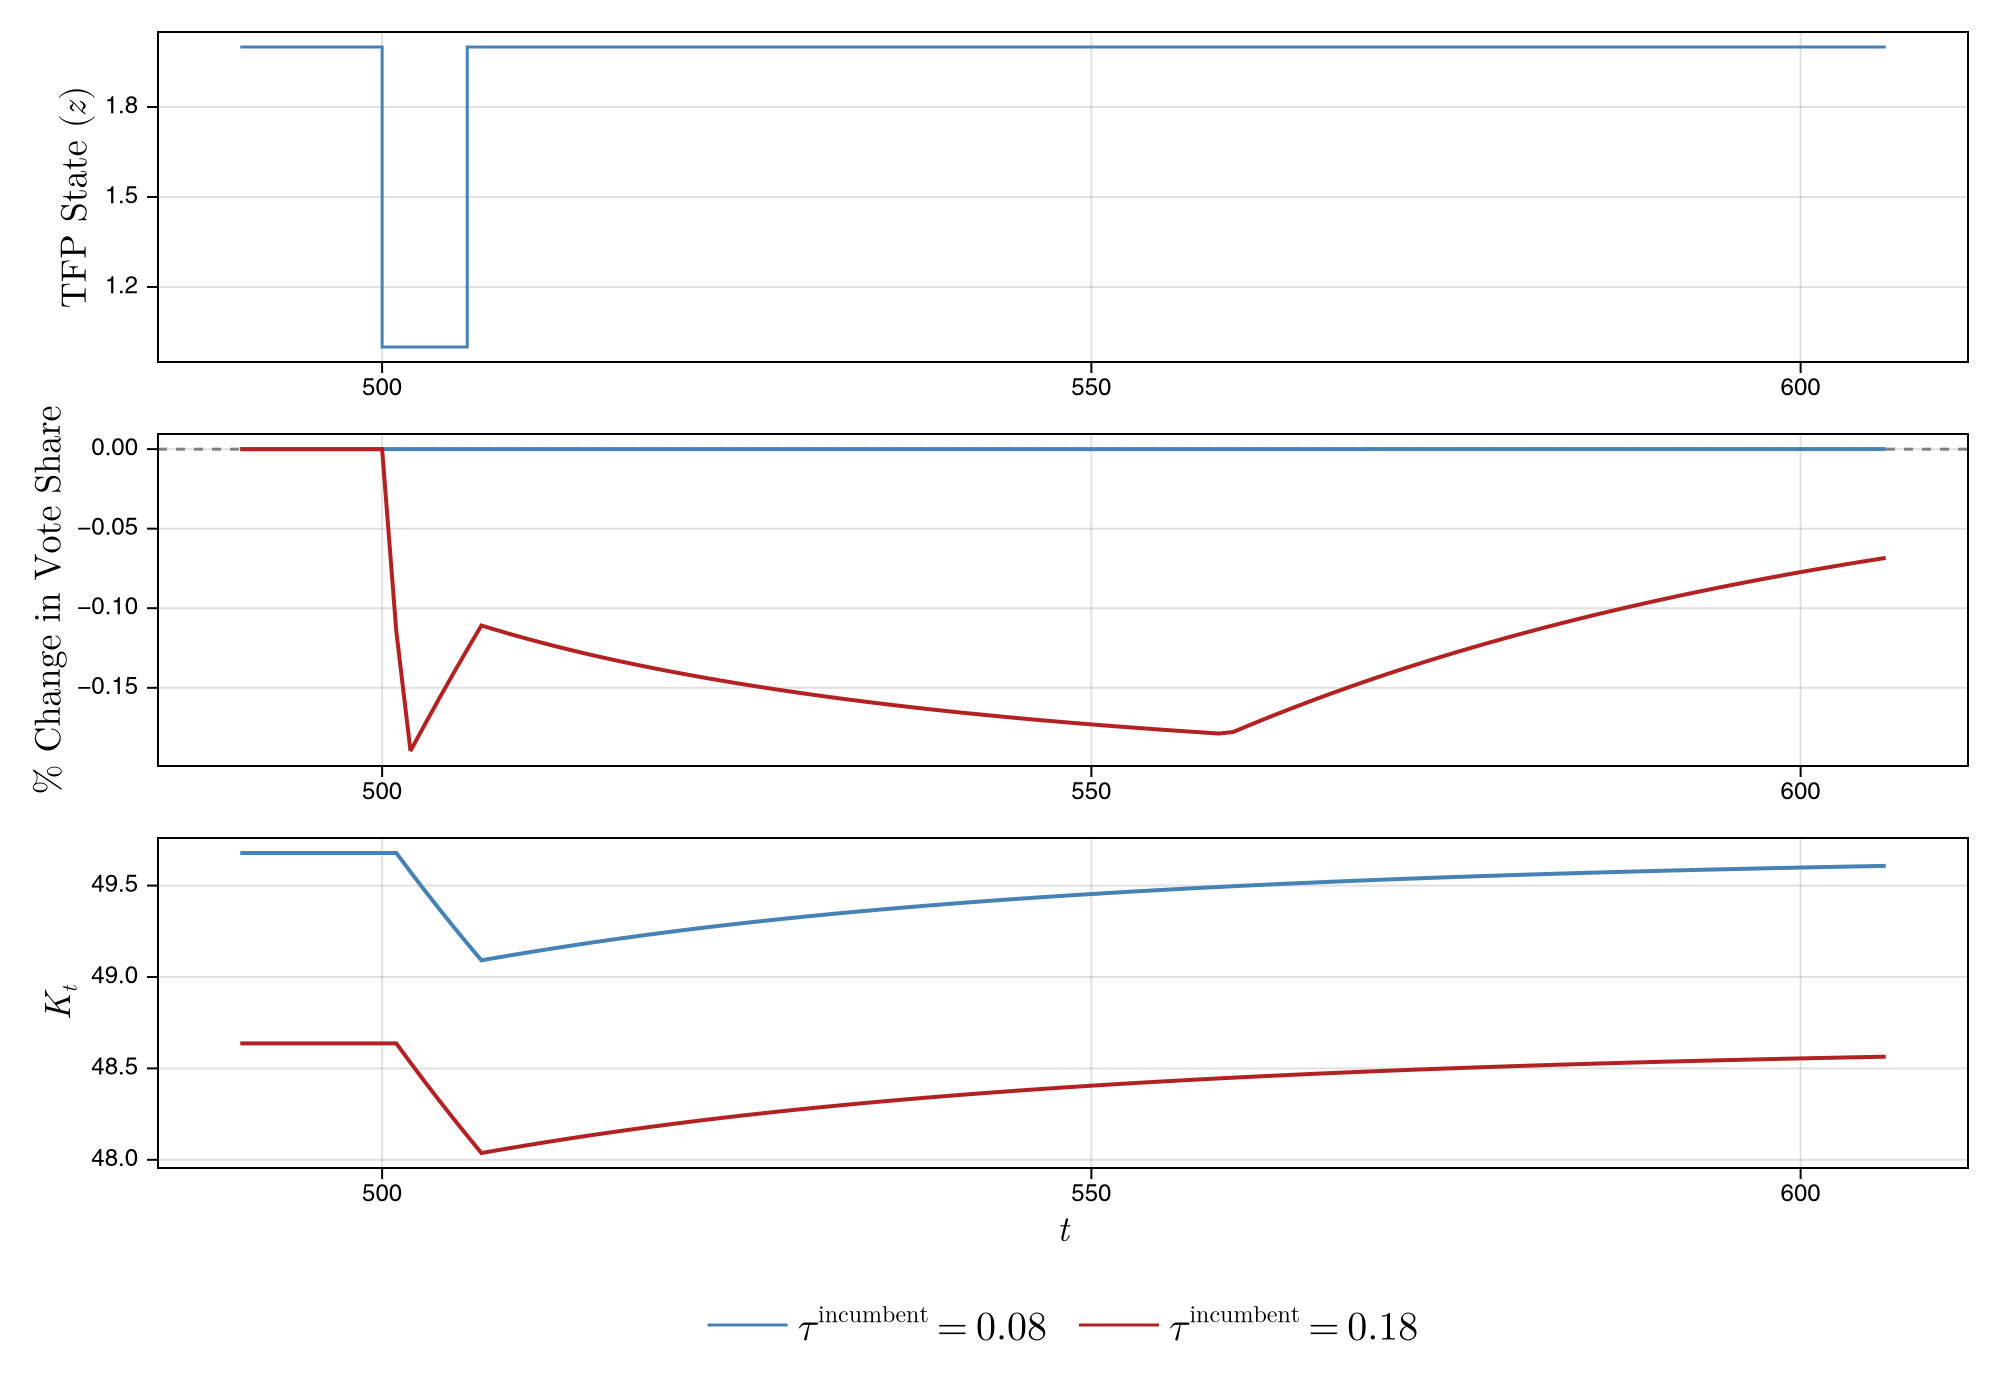

In [42]:

incumbent  = results[(0.08, 0.08)]   # some migration, no redistribution
challenger = results[(0.04, 0.18)]   # no migration, some redistribution
incumbent2  = results[(0.08, 0.14)]   # some migration, high redistribution

share_path, Kt = voteSharePath(incumbent, challenger, zt_shock, params);
share_path2, Kt2 = voteSharePath(incumbent2, challenger, zt_shock, params);
NT = length(share_path)
window = 490:(NT-400)

# baseline = pre-shock level, taken at the first period in the window
base1 = share_path[window[1]]
base2 = share_path2[window[1]]

pct1 = (share_path .- base1) ./ base1 .* 100
pct2 = (share_path2 .- base2) ./ base2 .* 100


# baseline = pre-shock level, taken at the first period in the window
base1 = share_path[window[1]]
base2 = share_path2[window[1]]

pct1 = (share_path .- base1) ./ base1 .* 100
pct2 = (share_path2 .- base2) ./ base2 .* 100


fig = Figure(size = (700, 500))

ax1 = Axis(fig[1, 1], ylabel = "z index", title = "Shock path")
stairs!(ax1, window, zt_shock[window])

ax2 = Axis(fig[2, 1], ylabel = "vote share", xlabel = "t")
l1 = lines!(ax2, window, share_path[window], color = :steelblue, label = "τ incumbent = 0.09")
l2 = lines!(ax2, window, share_path2[window], color = :firebrick, label = "τ incumbent = 0.135")
axislegend(ax2, position = :rt)

ax3 = Axis(fig[3, 1], ylabel = "Kt", xlabel = "t")
lines!(ax3, window, Kt[window], color = :steelblue)
lines!(ax3, window, Kt2[window], color = :firebrick)

linkxaxes!(ax1, ax2, ax3)
fig


In [ ]:


fig = Figure(size = (1000, 700))

ax1 = Axis(fig[1, 1],
    ylabel = L"\text{TFP State }(z)")
stairs!(ax1, window, zt_shock[window], color = :steelblue)

ax2 = Axis(fig[2, 1],
    ylabel = L"\text{\% Change in Vote Share}")
hlines!(ax2, [0.0], linestyle = :dash, color = :gray)
lines!(ax2, window, pct1[window], color = :steelblue, linewidth = 2)
lines!(ax2, window, pct2[window], color = :firebrick, linewidth = 2)

ax3 = Axis(fig[3, 1],
    xlabel = L"t",
    ylabel = L"K_t")
lines!(ax3, window, Kt[window], color = :steelblue, linewidth = 2)
lines!(ax3, window, Kt2[window], color = :firebrick, linewidth = 2)

# legend in its own column, spanning all three rows
Legend(fig[4, 1],
    [l1, l2],
    [L"\tau^{\text{incumbent}} = 0.08", L"\tau^{\text{incumbent}} = 0.18"],
    orientation = :horizontal,
    framevisible = false,
    labelsize = 20,
    patchsize = (40, 20),
    linewidth = 4)

rowsize!(fig.layout, 4, Relative(0.08))

linkxaxes!(ax1, ax2, ax3)

save("../v/vote_share_shock_comparison_HSV_quarterly.pdf", fig)
fig

# peak deviation (most negative point) for each
peak1, t_peak1 = findmin(pct1[window])
peak2, t_peak2 = findmin(pct2[window])
@printf("τ=0.08 peak: %.3f%% at t=%i\n", peak1, window[t_peak1])
@printf("τ=0.18 peak: %.3f%% at t=%i\n", peak2, window[t_peak2])

# recovery time: first period after the trough where |pct change| < some threshold
function recovery_time(pct, window, thresh=0.05)
    pct_w = pct[window]                      # local, window-relative series
    trough_idx = argmin(pct_w)               # local index of the trough
    for i in trough_idx:length(pct_w)
        if abs(pct_w[i]) < thresh
            return window[i]                 # map back to real t only here
        end
    end
    return nothing
end

thresh = 0.05
t1 = recovery_time(pct1, window, thresh)
t2 = recovery_time(pct2, window, thresh)

shock_end = 508
@printf("τ=0.08 recovers by t=%s (%s periods after shock ends)\n",
    t1, t1 === nothing ? "N/A" : string(t1 - shock_end))
@printf("τ=0.18 recovers by t=%s (%s periods after shock ends)\n",
    t2, t2 === nothing ? "N/A" : string(t2 - shock_end))

time_negative(pct, window) = count(x -> x < 0, pct[window])

neg1 = time_negative(pct1, window)
neg2 = time_negative(pct2, window)

@printf("τ=0.08: %i periods with negative deviation\n", neg1)
@printf("τ=0.18: %i periods with negative deviation\n", neg2)

fig

In [21]:
using LinearAlgebra: dot

Kmed = we*params.Kgrid[ix] + (1-we)*params.Kgrid[ix+1]
stat_l = stationary(params.π_l)

τ_grid = range(0, .18, 50)
η_grid = range(0, .18. 50)

λ_vals_tau = zeros(length(τ_grid))
top_net_income = zeros(length(τ_grid))

for (i, τ) in enumerate(τ_grid)
    w = calcw(params.α, Kmed, 0.0, zmed)   # η=0, isolating τ's effect
    denom = dot((w .* params.lgrid).^(1 - τ), stat_l)
    tot_inc = w * dot(params.lgrid, stat_l)
    λ_vals_tau[i] = tot_inc / denom
    top_net_income[i] = λ_vals_tau[i] * (w * lgrid[end])^(1 - τ)
end

@printf("Evaluated at K=%.4f, z=%.4f\n", Kmed, zmed)
for i in eachindex(τ_grid)
    @printf("  τ=%.4f -> λ=%.6f, top net income=%.4f\n",
            τ_grid[i], λ_vals_tau[i], top_net_income[i])
end

@printf("Evaluated at K=%.4f, z=%.4f\n", Kmed, zmed)
for i in eachindex(τ_grid)
    @printf("  τ=%.4f -> λ=%.6f, top net income=%.4f\n",
            τ_grid[i], λ_vals_tau[i], top_net_income[i])
end


fig = Figure(size=(700, 400))

ax1 = Axis(fig[1,1], xlabel="τ", ylabel="λ", title="λ vs τ")
lines!(ax1, τ_grid, λ_vals_tau)
scatter!(ax1, τ_grid, λ_vals_tau)

ax2 = Axis(fig[1,2], xlabel="τ", ylabel="top earner net income", title="Top earner net income vs τ")
lines!(ax2, τ_grid, top_net_income)
scatter!(ax2, τ_grid, top_net_income)

fig


LoadError: UndefVarError: `we` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [22]:
K_choice = 40.0   # or whatever K you actually mean to evaluate at, quarterly-appropriate
ix_test, we_test = weight(Kgrid, K_choice)
println("Evaluating at Kgrid[ix] = ", Kgrid[ix_test], ", target was ", ix_test)

K_base

LoadError: UndefVarError: `Kgrid` not defined in `Main`
Suggestion: check for spelling errors or missing imports.